# Load Images #

In [19]:
# step1_tidy.py
# ─────────────────────────────────────────────────────────────────
# What this does:
#   1. Renames person folders to clean canonical names
#      (strips whitespace, fixes capitalisation)
#   2. Converts every image to .jpg  (handles .png, .JPEG, .JPG etc.)
#   3. Renames all files to a clean zero-padded sequence
#      e.g.  img1.jpg / IMG_3233.jpg / Joe_Olivetti1.jpg → 001.jpg
#   4. Removes the original non-jpg files after conversion
#   5. Prints a summary table at the end
#
# Run from the folder that CONTAINS photos_final/
# ─────────────────────────────────────────────────────────────────

import os
import shutil
from pathlib import Path
from PIL import Image
import cv2
import numpy as np
import pickle

# ── CONFIG ───────────────────────────────────────────────────────
INPUT_ROOT  = Path("photos_final")
OUTPUT_ROOT = Path("photos_clean")       # new clean copy; original untouched
VALID_EXTS  = {".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"}
JPEG_QUALITY = 95

# Canonical name mapping  →  strip + title-case handles most cases,
# but explicit overrides catch edge cases like "roy" → "Roy"
NAME_OVERRIDES = {
    # "folder name as-is": "canonical name"
    # Add any that title-case gets wrong (acronyms, etc.)
}

# ─────────────────────────────────────────────────────────────────

def canonical_name(raw: str) -> str:
    stripped = raw.strip()
    if stripped in NAME_OVERRIDES:
        return NAME_OVERRIDES[stripped]
    return stripped.title()   # "roy" → "Roy", "Mikail " → "Mikail"


def to_jpg(src_path: Path, dst_path: Path, quality: int = JPEG_QUALITY):
    """Convert any image format to JPEG and save to dst_path."""
    img = Image.open(src_path).convert("RGB")   # RGB drops alpha channel safely
    img.save(dst_path, "JPEG", quality=quality)


def collect_images(folder: Path) -> list[Path]:
    """Recursively find all valid image files under folder."""
    found = []
    for p in sorted(folder.rglob("*")):
        if p.is_file() and p.suffix in VALID_EXTS:
            found.append(p)
    return found

# Add this to preprocess_functions.py

from PIL import Image as PILImage
import io

def fix_exif_rotation(img_bgr: np.ndarray, img_path: str | Path) -> np.ndarray:
    """
    Correct image rotation based on EXIF orientation tag.
    
    OpenCV ignores EXIF tags — this reads the tag via PIL and 
    applies the correct rotation before any processing.
    Returns the corrected BGR image.
    """
    try:
        pil_img = PILImage.open(str(img_path))
        exif    = pil_img._getexif()
        if exif is None:
            return img_bgr
        
        orientation = exif.get(274, 1)   # tag 274 = Orientation
        
        rotations = {
            3: cv2.ROTATE_180,
            6: cv2.ROTATE_90_CLOCKWISE,
            8: cv2.ROTATE_90_COUNTERCLOCKWISE
        }

        if orientation in rotations:
            return cv2.rotate(img_bgr, rotations[orientation])
        
    except Exception:
        pass

    return img_bgr   # no tag or no fix needed — return unchanged




In [ ]:
# ── Main ─────────────────────────────────────────────────────────
OUTPUT_ROOT.mkdir(exist_ok=True)

summary = []   # (canonical_name, n_images)

# Gather all person folders, group by canonical name
# (handles "Jasper" + "Jasper " → same bucket)
buckets: dict[str, list[Path]] = {}

for entry in sorted(INPUT_ROOT.iterdir()):
    if not entry.is_dir():
        continue
    name = canonical_name(entry.name)
    if name not in buckets:
        buckets[name] = []
    buckets[name] += collect_images(entry)

# Process each person
for name, img_paths in sorted(buckets.items()):
    out_dir = OUTPUT_ROOT / name
    out_dir.mkdir(exist_ok=True)

    converted = 0
    skipped   = 0

    for idx, src in enumerate(img_paths, start=1):
        dst = out_dir / f"{idx:03d}.jpg"
        try:
            to_jpg(src, dst)
            converted += 1
        except Exception as e:
            print(f"  [ERROR] {src.name}: {e}")
            skipped += 1

    summary.append((name, converted, skipped))
    print(f"  {name:<12}  {converted:>3} images saved  ({skipped} skipped)")

# ── Summary table ────────────────────────────────────────────────
print(f"\n{'─'*45}")
print(f"  {'Person':<12}  {'Saved':>6}  {'Skipped':>7}")
print(f"{'─'*45}")
total = 0
for name, saved, skipped in summary:
    flag = "  ⚠ low" if saved < 10 else ""
    print(f"  {name:<12}  {saved:>6}  {skipped:>7}{flag}")
    total += saved
print(f"{'─'*45}")
print(f"  {'TOTAL':<12}  {total:>6}")
print(f"\nOutput written to: {OUTPUT_ROOT.resolve()}")
print("Original photos_final/ is untouched.")

## Data Preprocessing ##

In [ ]:
# preprocess_functions.py
# ─────────────────────────────────────────────────────────────────
# All preprocessing steps as standalone functions.
# Call them individually or chain them in order.
#""
# Pipeline order:
#   1. load_image(path)
#   2. detect_face(img_bgr)
#   3. align_face(gray, x, y, w, h)
#   4. crop_face(gray, x, y, w, h, img_shape)
#   5. resize_face(face_gray)
#   6. normalize_lighting(face_gray)
#   7. apply_ellipse_mask(face_gray)
#   8. save_face(face_gray, out_path)
# ─────────────────────────────────────────────────────────────────

import cv2
import numpy as np
from pathlib import Path

# ── Cascades (loaded once at module level) ────────────────────────
_face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)
_eye_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_eye.xml"
)

# ── CONFIG ────────────────────────────────────────────────────────
FACE_SIZE       = (90, 90)
CLAHE_CLIP      = 2.0
CLAHE_GRID      = (8, 8)
FOREHEAD_EXTRA  = 0.15   # fraction of h to add above face box
CHIN_EXTRA      = 0.05   # fraction of h to add below face box
MAX_TILT_ANGLE  = 30.0   # degrees; skip rotation if tilt exceeds this


# ═════════════════════════════════════════════════════════════════
# STEP 1 — Load image
# ═════════════════════════════════════════════════════════════════
def load_image(path: str | Path) -> np.ndarray | None:
    """
    Load an image from disk and return as BGR numpy array.

    Returns None if the file cannot be read.

    Usage:
        img = load_image("photos_clean/Roy/001.jpg")
        if img is None:
            print("Could not load image")
    """
    img = cv2.imread(str(path))
    if img is None:
        print(f"  [load_image] Could not read: {path}")
    return img


# ═════════════════════════════════════════════════════════════════
# STEP 2 — Detect face (Viola-Jones)
# ═════════════════════════════════════════════════════════════════
def detect_face(img_bgr: np.ndarray) -> tuple | None:
    """
    Detect the largest face in a BGR image using Viola-Jones (Haar cascade).

    Tries progressively looser detection params until a face is found.
    Returns (x, y, w, h) of the largest detected face, or None.

    Why progressively looser:
        scaleFactor=1.05 is tight — catches more faces but slower.
        We try tight first, loosen only if nothing found.
        minNeighbors=4 avoids false positives in cluttered backgrounds.

    Usage:
        face_rect = detect_face(img)
        if face_rect is None:
            print("No face found")
        else:
            x, y, w, h = face_rect
    """
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    for (scale, neighbors) in [(1.05, 4), (1.1, 4), (1.15, 3), (1.2, 2)]:
        faces = _face_cascade.detectMultiScale(
            gray,
            scaleFactor=scale,
            minNeighbors=neighbors,
            minSize=(40, 40)
        )
        if len(faces) > 0:
            # Pick the largest detection — most likely the primary face
            faces = sorted(faces, key=lambda f: f[2] * f[3], reverse=True)
            return tuple(faces[0])   # (x, y, w, h)

    print("  [detect_face] No face detected")
    return None


# ═════════════════════════════════════════════════════════════════
# STEP 3 — Align face (rotation correction via eye detection)
# ═════════════════════════════════════════════════════════════════
def align_face(
    gray: np.ndarray,
    x: int, y: int, w: int, h: int
) -> tuple[np.ndarray, int, int, int, int]:
    """
    Correct head tilt by detecting both eyes and rotating the full
    grayscale image so the eye line becomes horizontal.

    Searches for eyes only in the TOP HALF of the face bounding box
    (avoids false positives from nostrils and mouth).

    Sanity checks before rotating:
        - Requires exactly 2 eye candidates
        - Eyes must be separated by at least 20% of face width
          (rejects noise detections that are too close together)
        - Tilt must be < MAX_TILT_ANGLE degrees
          (large angles usually mean a bad eye detection)

    Returns (aligned_gray, x, y, w, h).
    If alignment fails any check, returns the original gray UNCHANGED
    — the face rect is still valid for cropping.

    Usage:
        aligned, x, y, w, h = align_face(gray, x, y, w, h)
        # aligned is the full rotated grayscale image
        # x,y,w,h still valid for cropping from aligned
    """
    face_roi = gray[y: y + h // 2, x: x + w]   # top half only

    eyes = _eye_cascade.detectMultiScale(
        face_roi,
        scaleFactor=1.1,
        minNeighbors=8,
        minSize=(15, 15)
        # no maxSize — kills detection on small/close-up faces
    )

    if len(eyes) < 2:
        print(f"  [align_face] < 2 eyes found — skipping rotation")
        return gray, x, y, w, h

    # Take the two largest eye candidates
    eyes = sorted(eyes, key=lambda e: e[2] * e[3], reverse=True)[:2]
    eyes = sorted(eyes, key=lambda e: e[0])   # left → right by x

    (ex1, ey1, ew1, eh1) = eyes[0]
    (ex2, ey2, ew2, eh2) = eyes[1]

    # Reconstruct full-image coordinates
    # face_roi starts at (x, y) in the full image
    left_eye_center  = (x + ex1 + ew1 // 2,  y + ey1 + eh1 // 2)
    right_eye_center = (x + ex2 + ew2 // 2,  y + ey2 + eh2 // 2)

    # Sanity: eyes must be far enough apart
    eye_gap = abs(right_eye_center[0] - left_eye_center[0])
    if eye_gap < w * 0.20:
        print(f"  [align_face] Eyes too close ({eye_gap}px) — skipping rotation")
        return gray, x, y, w, h

    # Compute tilt angle
    dx    = right_eye_center[0] - left_eye_center[0]
    dy    = right_eye_center[1] - left_eye_center[1]
    angle = np.degrees(np.arctan2(dy, dx))

    if abs(angle) > MAX_TILT_ANGLE:
        print(f"  [align_face] Tilt {angle:.1f}° > {MAX_TILT_ANGLE}° — skipping rotation")
        return gray, x, y, w, h

    # Rotate around the midpoint between the eyes
# In align_face(), replace the eye_mid block:

    eye_mid = (
        float((left_eye_center[0] + right_eye_center[0]) // 2),
        float((left_eye_center[1] + right_eye_center[1]) // 2)
    )
    M       = cv2.getRotationMatrix2D(eye_mid, angle, 1.0)
    aligned = cv2.warpAffine(
        gray, M, (gray.shape[1], gray.shape[0]),
        flags=cv2.INTER_CUBIC,
        borderMode=cv2.BORDER_REPLICATE   # fills gaps with edge pixels
    )

    print(f"  [align_face] Rotated {angle:.1f}°")
    return aligned, x, y, w, h


# ═════════════════════════════════════════════════════════════════
# STEP 4 — Crop face region
# ═════════════════════════════════════════════════════════════════
def crop_face(
    gray: np.ndarray,
    x: int, y: int, w: int, h: int
) -> np.ndarray | None:
    """
    Crop the face region from the (possibly aligned) grayscale image.

    Uses Olivetti-style asymmetric margins:
        - Forehead: +15% of h  (foreheads add discriminative info)
        - Chin:     + 5% of h  (chins vary more; keep tight)
        - Sides:      0% extra (Viola-Jones box already covers ears)

    Clamps all coordinates to image bounds before slicing.
    Returns the cropped grayscale face, or None if crop is empty.

    Usage:
        face_crop = crop_face(aligned_gray, x, y, w, h)
        if face_crop is None:
            print("Empty crop — skip this image")
    """
    img_h, img_w = gray.shape[:2]

    forehead = int(h * FOREHEAD_EXTRA)
    chin     = int(h * CHIN_EXTRA)

    x1 = max(0,     x)
    y1 = max(0,     y - forehead)
    x2 = min(img_w, x + w)
    y2 = min(img_h, y + h + chin)

    crop = gray[y1:y2, x1:x2]

    if crop.size == 0:
        print("  [crop_face] Empty crop — skipping")
        return None

    return crop


# ═════════════════════════════════════════════════════════════════
# STEP 5 — Resize to standard size
# ═════════════════════════════════════════════════════════════════
def resize_face(face_gray: np.ndarray, size: tuple = FACE_SIZE) -> np.ndarray:
    """
    Resize face crop to the standard size (default 90×90).

    Uses INTER_AREA interpolation — averages pixel blocks when
    downsampling, which reduces aliasing better than INTER_LINEAR.

    All training AND live-camera faces must go through this same
    function to guarantee identical dimensions for Fisherfaces.

    Usage:
        resized = resize_face(face_crop)          # → (90, 90)
        resized = resize_face(face_crop, (112,112))  # custom size
    """
    return cv2.resize(face_gray, size, interpolation=cv2.INTER_AREA)


# ═════════════════════════════════════════════════════════════════
# STEP 6 — Normalize lighting (CLAHE + min-max stretch)
# ═════════════════════════════════════════════════════════════════
def normalize_lighting(face_gray: np.ndarray) -> np.ndarray:
    """
    Two-stage illumination normalization:

    Stage A — CLAHE (Contrast Limited Adaptive Histogram Equalization):
        Divides the image into 8×8 tiles and equalizes each tile
        independently. The clipLimit=2.0 prevents over-amplifying
        noise in flat regions (e.g. forehead, cheeks).
        This corrects LOCAL lighting variation (one-sided light,
        shadows from nose/brow).

    Stage B — cv2.normalize (global min-max stretch):
        Stretches pixel values to the full [0, 255] range.
        Corrects GLOBAL brightness offset (e.g. dim overall image).

    Why both? CLAHE fixes contrast locally; normalize fixes
    the global offset. Together they handle the most common
    lighting problems in phone selfies.

    Usage:
        normalized = normalize_lighting(resized_face)
    """
    clahe      = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=CLAHE_GRID)
    clahe_img  = clahe.apply(face_gray)
    normalized = cv2.normalize(clahe_img, None, 0, 255, cv2.NORM_MINMAX)
    return normalized


# ═════════════════════════════════════════════════════════════════
# STEP 7 — Ellipse mask
# ═════════════════════════════════════════════════════════════════
def apply_ellipse_mask(face_gray: np.ndarray) -> np.ndarray:
    """
    Zero out pixels outside an oval region centred on the face.

    Why: Even after a tight Viola-Jones crop, the four corners
    contain background (wall, hair edges, clothing collar).
    PCA treats every pixel equally — corner background pixels
    add variance that has nothing to do with identity.
    The ellipse removes them cleanly.

    Axes are tuned for a 90×90 face:
        rx = 45% of width  → covers cheeks to ears
        ry = 48% of height → covers forehead to chin

    Pixels outside the ellipse are set to 0 (black).

    Usage:
        masked = apply_ellipse_mask(normalized_face)
    """
    h, w  = face_gray.shape
    mask  = np.zeros((h, w), dtype=np.uint8)
    cv2.ellipse(
        mask,
        center=(w // 2, h // 2),
        axes=(int(w * 0.45), int(h * 0.48)),
        angle=0, startAngle=0, endAngle=360,
        color=255, thickness=-1   # filled ellipse
    )
    result = face_gray.copy()
    result[mask == 0] = 0
    return result


# ═════════════════════════════════════════════════════════════════
# STEP 8 — Save processed face
# ═════════════════════════════════════════════════════════════════
def save_face(face_gray: np.ndarray, out_path: str | Path) -> bool:
    """
    Save a processed grayscale face image to disk.

    Creates parent directories if they don't exist.}
    Returns True on success, False on failure.

    Usage:
        save_face(masked_face, "processed_gallery/Roy/001.png")
    """
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    ok = cv2.imwrite(str(out_path), face_gray)
    if not ok:
        print(f"  [save_face] Failed to write: {out_path}")
    return ok

: 

In [5]:
fazil = load_image("/Users/fazil/Desktop/EE4228/IE4228-Assignment/[FINAL] Assignment 1/photos_clean/Fazil/011.jpg")

In [7]:
fazil_face = detect_face(fazil)

  [align_face] Rotated -8.0°


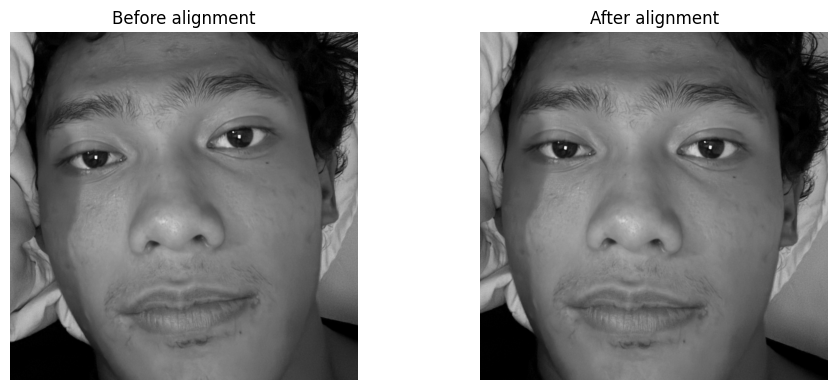

In [19]:
gray = cv2.cvtColor(fazil, cv2.COLOR_BGR2GRAY)
x, y, w, h = fazil_face
aligned, x, y, w, h = align_face(gray, x, y, w, h)

# Visualise before vs after alignment
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(gray[y:y+h, x:x+w], cmap="gray")
plt.title("Before alignment")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(aligned[y:y+h, x:x+w], cmap="gray")
plt.title("After alignment")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
gray = cv2.cvtColor(fazil, cv2.COLOR_BGR2GRAY)
x, y, w, h = fazil_face

# Detect eyes manually to get their coordinates
face_roi = gray[y: y + h // 2, x: x + w]
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_eye.xml")
eyes = eye_cascade.detectMultiScale(face_roi, scaleFactor=1.1, minNeighbors=8, minSize=(15, 15))

# Draw face box + eye boxes on a colour copy
viz = fazil.copy()
cv2.rectangle(viz, (x, y), (x+w, y+h), (0, 255, 0), 2)   # face — green

for (ex, ey, ew, eh) in eyes:
    # eye coords are relative to face_roi, convert back to full image
    cv2.rectangle(viz,
                  (x + ex,      y + ey),
                  (x + ex + ew, y + ey + eh),
                  (255, 0, 0), 2)   # eyes — blue

# Show
viz_rgb = cv2.cvtColor(viz, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8, 6))
plt.imshow(viz_rgb)
plt.title(f"Face (green) + Eyes detected (blue) — {len(eyes)} eye(s) found")
plt.axis("off")
plt.show()

print(f"Eyes found: {len(eyes)}")
for i, (ex, ey, ew, eh) in enumerate(eyes):
    print(f"  Eye {i+1}: x={x+ex}, y={y+ey}, w={ew}, h={eh}")

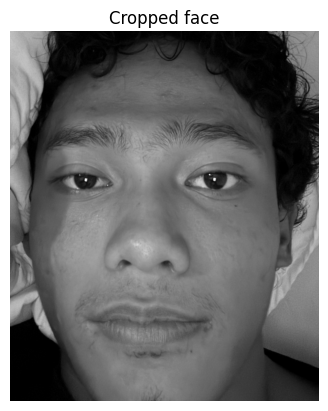

In [20]:
crop  = crop_face(aligned,x,y,w,h)
plt.imshow(crop, cmap="gray")
plt.title("Cropped face")
plt.axis("off")
plt.show()

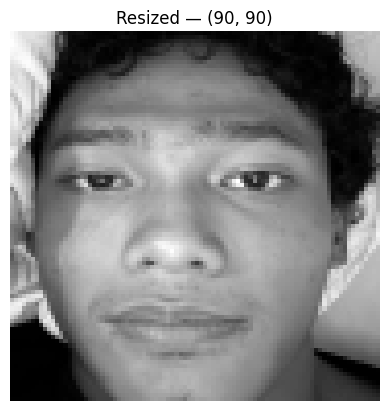

In [21]:
resized = resize_face(crop)

plt.imshow(resized, cmap="gray")
plt.title(f"Resized — {resized.shape}")
plt.axis("off")
plt.show()

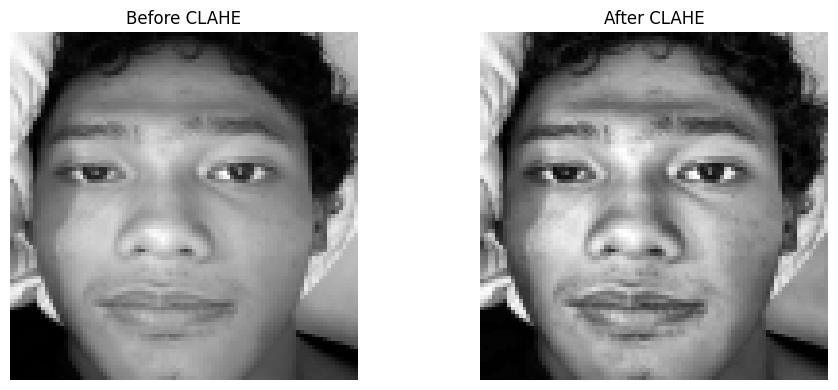

In [22]:
normed = normalize_lighting(resized)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(resized, cmap="gray")
plt.title("Before Normalization")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(normed, cmap="gray")
plt.title("After Normalization")
plt.axis("off")

plt.tight_layout()
plt.show()

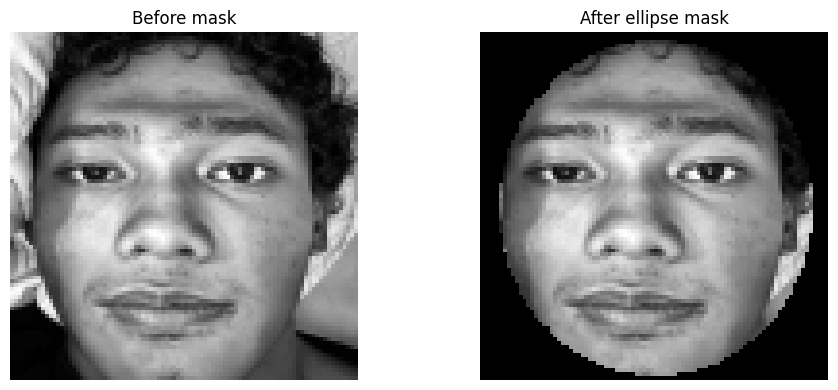

In [23]:
masked = apply_ellipse_mask(normed)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(normed, cmap="gray")
plt.title("Before mask")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(masked, cmap="gray")
plt.title("After ellipse mask")
plt.axis("off")

plt.tight_layout()
plt.show()

## Data Preprocessing Batch##

In [26]:
# batch_preprocess.py
# Runs the full pipeline on all images in photos_clean/
# and saves results to processed_gallery/

import os
import cv2
import numpy as np
import pickle
from pathlib import Path


INPUT_ROOT  = Path("photos_clean")
OUTPUT_ROOT = Path("processed_gallery")

# ── Tracking ──────────────────────────────────────────────────────
all_images  = []
all_labels  = []
all_names   = []

summary     = []   # per person stats
all_failed  = {}   # person → list of filenames that failed

# ── Main loop ─────────────────────────────────────────────────────
person_dirs = sorted([p for p in INPUT_ROOT.iterdir() if p.is_dir()])

for label_id, person_dir in enumerate(person_dirs):
    name     = person_dir.name
    img_paths = sorted(person_dir.glob("*.jpg"))

    all_names.append(name)
    all_failed[name] = []

    saved   = 0
    failed  = 0
    no_eye  = 0

    print(f"\n{'─'*45}")
    print(f"  {name}  (label {label_id})")
    print(f"{'─'*45}")

    for img_path in img_paths:

        # Step 1 — load
        img = load_image(img_path)
        if img is None:
            print(f"  [SKIP] Cannot read: {img_path.name}")
            all_failed[name].append(img_path.name)
            failed += 1
            continue

        # Step 2 — detect
        face_rect = detect_face(img)
        if face_rect is None:
            print(f"  [NO FACE] {img_path.name}")
            all_failed[name].append(img_path.name)
            failed += 1
            continue

        x, y, w, h = face_rect
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Step 3 — align
        aligned, x, y, w, h = align_face(gray, x, y, w, h)
        if np.array_equal(aligned, gray):
            no_eye += 1   # alignment skipped, still continues

        # Step 4 — crop
        crop = crop_face(aligned, x, y, w, h)
        if crop is None:
            print(f"  [EMPTY CROP] {img_path.name}")
            all_failed[name].append(img_path.name)
            failed += 1
            continue

        # Step 5 — resize
        resized = resize_face(crop)

        # Step 6 — normalize lighting
        normed = normalize_lighting(resized)

        # Step 7 — ellipse mask
        masked = apply_ellipse_mask(normed)

        # Step 8 — save
        out_path = OUTPUT_ROOT / name / f"{saved+1:03d}.png"
        save_face(masked, out_path)

        all_images.append(masked)
        all_labels.append(label_id)
        saved += 1
        print(f"  ✓  {img_path.name}")

    summary.append((name, saved, failed, no_eye))

# ── Save dataset.pkl ──────────────────────────────────────────────
with open("dataset.pkl", "wb") as f:
    pickle.dump({
        "images": all_images,
        "labels": all_labels,
        "names":  all_names
    }, f)

# ── Summary table ─────────────────────────────────────────────────
print(f"\n{'═'*55}")
print(f"  {'Person':<12} {'Saved':>6}  {'Failed':>7}  {'No Eyes':>8}")
print(f"{'─'*55}")
total_saved = total_failed = 0
for name, saved, failed, no_eye in summary:
    flag = "  ⚠ check" if failed > 0 else ""
    print(f"  {name:<12} {saved:>6}  {failed:>7}  {no_eye:>8}{flag}")
    total_saved  += saved
    total_failed += failed
print(f"{'─'*55}")
print(f"  {'TOTAL':<12} {total_saved:>6}  {total_failed:>7}")
print(f"{'═'*55}")

# ── Failed file list ──────────────────────────────────────────────
any_failed = any(len(v) > 0 for v in all_failed.values())
if any_failed:
    print(f"\n  Files with no face detected:")
    print(f"{'─'*45}")
    for name, files in all_failed.items():
        if files:
            print(f"\n  {name}:")
            for f in files:
                print(f"    ✗  {f}")

print(f"\n  dataset.pkl saved — {total_saved} images, {len(all_names)} people")
print(f"  Label mapping: { {i: n for i, n in enumerate(all_names)} }")


─────────────────────────────────────────────
  Fathiah  (label 0)
─────────────────────────────────────────────
  [align_face] < 2 eyes found — skipping rotation
  ✓  001.jpg
  [align_face] < 2 eyes found — skipping rotation
  ✓  002.jpg
  [align_face] < 2 eyes found — skipping rotation
  ✓  003.jpg
  [align_face] < 2 eyes found — skipping rotation
  ✓  004.jpg
  [align_face] < 2 eyes found — skipping rotation
  ✓  005.jpg
  [align_face] < 2 eyes found — skipping rotation
  ✓  006.jpg
  [align_face] < 2 eyes found — skipping rotation
  ✓  007.jpg
  [align_face] Rotated 5.3°
  ✓  008.jpg
  [align_face] < 2 eyes found — skipping rotation
  ✓  009.jpg
  [align_face] < 2 eyes found — skipping rotation
  ✓  010.jpg
  [align_face] < 2 eyes found — skipping rotation
  ✓  011.jpg
  [align_face] < 2 eyes found — skipping rotation
  ✓  012.jpg
  [align_face] < 2 eyes found — skipping rotation
  ✓  013.jpg
  [align_face] < 2 eyes found — skipping rotation
  ✓  014.jpg
  [align_face] < 2 eyes fo

In [35]:
import os
import cv2
import pickle
from pathlib import Path


# ── CONFIG ────────────────────────────────────────────────────────
PERSON      = "Syarah"          # change to whichever class has the issue
INPUT_DIR   = Path(f"photos_clean/{PERSON}")
OUTPUT_DIR  = Path(f"processed_gallery/{PERSON}")
DATASET_PKL = Path("dataset.pkl")

# ── Clear existing output for this person ─────────────────────────
import shutil
if OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True)
print(f"Cleared {OUTPUT_DIR}")

# ── Process without alignment ─────────────────────────────────────
saved  = 0
failed = 0
new_images = []
new_labels = []

# Load existing dataset to get the label id for this person
with open(DATASET_PKL, "rb") as f:
    data = pickle.load(f)

label_id = data["names"].index(PERSON)
print(f"Label ID for {PERSON}: {label_id}")

for img_path in sorted(INPUT_DIR.glob("*.jpg")):
    img = load_image(img_path)
    if img is None:
        failed += 1
        continue

    
    face_rect = detect_face(img)
    if face_rect is None:
        print(f"  [NO FACE] {img_path.name}")
        failed += 1
        continue

    x, y, w, h = face_rect
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # ── No alignment — go straight to crop ───────────────────────
    crop    = crop_face(gray, x, y, w, h)        # uses original gray
    if crop is None:
        failed += 1
        continue

    resized = resize_face(crop)
    normed  = normalize_lighting(resized)
    masked  = apply_ellipse_mask(normed)

    save_face(masked, OUTPUT_DIR / f"{saved+1:03d}.png")
    new_images.append(masked)
    new_labels.append(label_id)
    saved += 1
    print(f"  ✓  {img_path.name}")

print(f"\n  {PERSON}: {saved} saved, {failed} failed")

# ── Update dataset.pkl — replace this person's entries ───────────
old_images = data["images"]
old_labels = data["labels"]

# Remove old entries for this label_id
filtered_images = [img for img, lbl in zip(old_images, old_labels) if lbl != label_id]
filtered_labels = [lbl for lbl in old_labels if lbl != label_id]

# Add new entries
updated_images = filtered_images + new_images
updated_labels = filtered_labels + new_labels

data["images"] = updated_images
data["labels"] = updated_labels

with open(DATASET_PKL, "wb") as f:
    pickle.dump(data, f)

print(f"  dataset.pkl updated — total images: {len(updated_images)}")
print(f"  Label mapping: { {i: n for i, n in enumerate(data['names'])} }")

Cleared processed_gallery/Syarah
Label ID for Syarah: 6
  ✓  001.jpg
  ✓  002.jpg
  ✓  003.jpg
  ✓  004.jpg
  ✓  005.jpg
  ✓  006.jpg
  ✓  007.jpg
  ✓  008.jpg
  ✓  009.jpg
  ✓  010.jpg
  ✓  011.jpg
  ✓  012.jpg
  ✓  013.jpg
  ✓  014.jpg
  ✓  015.jpg
  ✓  016.jpg
  ✓  017.jpg
  ✓  018.jpg
  ✓  019.jpg
  ✓  020.jpg
  ✓  021.jpg
  ✓  022.jpg
  ✓  023.jpg
  ✓  024.jpg
  ✓  025.jpg
  ✓  026.jpg
  ✓  027.jpg
  ✓  028.jpg
  ✓  029.jpg
  ✓  030.jpg
  ✓  031.jpg

  Syarah: 31 saved, 0 failed
  dataset.pkl updated — total images: 142
  Label mapping: {0: 'Fathiah', 1: 'Fazil', 2: 'Jasper', 3: 'Joe', 4: 'Mikail', 5: 'Roy', 6: 'Syarah'}


In [36]:
# Quick check on what you have
import pickle
import numpy as np

with open("dataset.pkl", "rb") as f:
    data = pickle.load(f)

images = data["images"]
labels = data["labels"]
names  = data["names"]

print(f"Total images : {len(images)}")
print(f"People       : {names}")
print(f"Label mapping: { {i: n for i, n in enumerate(names)} }")
print()
print("Per-person count:")
for i, name in enumerate(names):
    count = labels.count(i)
    print(f"  {name:<12} {count:>3} images")

Total images : 142
People       : ['Fathiah', 'Fazil', 'Jasper', 'Joe', 'Mikail', 'Roy', 'Syarah']
Label mapping: {0: 'Fathiah', 1: 'Fazil', 2: 'Jasper', 3: 'Joe', 4: 'Mikail', 5: 'Roy', 6: 'Syarah'}

Per-person count:
  Fathiah       15 images
  Fazil         17 images
  Jasper        16 images
  Joe           20 images
  Mikail        21 images
  Roy           22 images
  Syarah        31 images


## Fisherface ##

In [1]:
# train.py
import pickle
import numpy as np
import cv2
import os
from pathlib import Path
from sklearn.model_selection import StratifiedShuffleSplit

# ── Load dataset ──────────────────────────────────────────────────
with open("dataset.pkl", "rb") as f:
    data = pickle.load(f)

images = np.array(data["images"])   # (142, 90, 90)
labels = np.array(data["labels"])   # (142,)
names  = data["names"]              # ['Fathiah', 'Fazil', ...]

print(f"Total images : {len(images)}")
print(f"People       : {names}\n")

# ── Train / test split (80/20, stratified) ────────────────────────
# Stratified = each person keeps same proportion in train and test
# e.g. Fathiah has 15 → 12 train, 3 test
#      Syarah  has 31 → 24 train, 7 test

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(sss.split(images, labels))

train_images = list(images[train_idx])
train_labels = labels[train_idx]
test_images  = list(images[test_idx])
test_labels  = labels[test_idx]

print("Train/test split (stratified 80/20):")
print(f"  Train : {len(train_images)} images")
print(f"  Test  : {len(test_images)}  images")
print()
print(f"  {'Person':<12} {'Train':>6} {'Test':>6}")
print(f"  {'─'*26}")
for i, name in enumerate(names):
    tr = np.sum(train_labels == i)
    te = np.sum(test_labels  == i)
    print(f"  {name:<12} {tr:>6} {te:>6}")

# ── Train Fisherfaces ─────────────────────────────────────────────
print("\nTraining Fisherfaces...")
model = cv2.face.FisherFaceRecognizer_create(
    num_components=0,     # 0 = auto → uses N_classes - 1 = 6 components
    threshold=float("inf")  # no threshold during training — we tune it separately
)
model.train(train_images, train_labels)
print("Training done.")

# ── Save model ────────────────────────────────────────────────────
os.makedirs("model", exist_ok=True)
model.save("model/fisherfaces.yml")

with open("model/names.pkl", "wb") as f:
    pickle.dump(names, f)

with open("model/test_set.pkl", "wb") as f:
    pickle.dump({
        "images": test_images,
        "labels": test_labels,
        "names":  names
    }, f)

print("Saved:")
print("  model/fisherfaces.yml")
print("  model/names.pkl")
print("  model/test_set.pkl  ← used for threshold tuning next")

# ── Quick sanity check on training set ───────────────────────────
print("\nSanity check — predicting on training set (should be ~100%):")
correct = 0
for img, lbl in zip(train_images, train_labels):
    pred_lbl, conf = model.predict(img)
    if pred_lbl == lbl:
        correct += 1
train_acc = correct / len(train_images) * 100
print(f"  Training accuracy: {train_acc:.1f}%")
print("  (If this is < 95%, something is wrong in preprocessing)")

Total images : 142
People       : ['Fathiah', 'Fazil', 'Jasper', 'Joe', 'Mikail', 'Roy', 'Syarah']

Train/test split (stratified 80/20):
  Train : 113 images
  Test  : 29  images

  Person        Train   Test
  ──────────────────────────
  Fathiah          12      3
  Fazil            13      4
  Jasper           13      3
  Joe              16      4
  Mikail           17      4
  Roy              17      5
  Syarah           25      6

Training Fisherfaces...
Training done.
Saved:
  model/fisherfaces.yml
  model/names.pkl
  model/test_set.pkl  ← used for threshold tuning next

Sanity check — predicting on training set (should be ~100%):
  Training accuracy: 100.0%
  (If this is < 95%, something is wrong in preprocessing)


## Test ##

In [21]:
import numpy as np
import pickle
import os
from pathlib import Path
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.svm import SVC

# ── PCA ───────────────────────────────────────────────────────────
class PCAReducer:
    def __init__(self, n_components):
        self.n_components = n_components
        self.mean         = None
        self.components   = None

    def fit(self, X):
        N, D = X.shape
        self.mean = X.mean(axis=0)
        X_centred = X - self.mean
        C_small   = X_centred @ X_centred.T / N
        eigenvalues, eigenvectors_small = np.linalg.eigh(C_small)
        idx          = np.argsort(eigenvalues)[::-1]
        eigenvalues  = eigenvalues[idx]
        eigenvectors_small = eigenvectors_small[:, idx]
        W     = X_centred.T @ eigenvectors_small
        norms = np.linalg.norm(W, axis=0, keepdims=True)
        norms[norms == 0] = 1
        W     = W / norms
        self.components  = W[:, :self.n_components].T
        self.eigenvalues = eigenvalues[:self.n_components]
        return self

    def transform(self, X):
        return (X - self.mean) @ self.components.T

    def fit_transform(self, X):
        return self.fit(X).transform(X)


# ── LDA ───────────────────────────────────────────────────────────
class LDAReducer:
    def __init__(self, n_components):
        self.n_components = n_components
        self.components   = None
        self.global_mean  = None

    def fit(self, X, y):
        N, K             = X.shape
        classes          = np.unique(y)
        self.global_mean = X.mean(axis=0)
        S_W = np.zeros((K, K))
        for c in classes:
            X_c    = X[y == c]
            mean_c = X_c.mean(axis=0)
            diff   = X_c - mean_c
            S_W   += diff.T @ diff
        S_B = np.zeros((K, K))
        for c in classes:
            X_c    = X[y == c]
            n_c    = len(X_c)
            mean_c = X_c.mean(axis=0)
            diff   = (mean_c - self.global_mean).reshape(-1, 1)
            S_B   += n_c * (diff @ diff.T)
        S_W_inv              = np.linalg.pinv(S_W)
        M                    = S_W_inv @ S_B
        eigenvalues, eigenvectors = np.linalg.eig(M)
        eigenvalues  = eigenvalues.real
        eigenvectors = eigenvectors.real
        idx          = np.argsort(eigenvalues)[::-1]
        eigenvectors = eigenvectors[:, idx]
        self.components = eigenvectors[:, :self.n_components].T
        return self

    def transform(self, X):
        return X @ self.components.T

    def fit_transform(self, X, y):
        return self.fit(X, y).transform(X)


# ── KNN ───────────────────────────────────────────────────────────
class KNNClassifier:
    def __init__(self, k=3):
        self.k       = k
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        self.X_train = X.copy()
        self.y_train = y.copy()
        return self

    def predict_one(self, x, threshold=None):
        dists  = np.sqrt(((self.X_train - x) ** 2).sum(axis=1))
        k_idx  = np.argsort(dists)[:self.k]
        k_lbls = self.y_train[k_idx]
        votes  = np.bincount(k_lbls, minlength=np.max(self.y_train)+1)
        pred   = np.argmax(votes)
        conf   = dists[k_idx[0]]
        if threshold is not None and conf > threshold:
            return -1, conf
        return pred, conf

    def predict(self, X, threshold=None):
        return [self.predict_one(x, threshold) for x in X]


# ── Nearest Centroid ──────────────────────────────────────────────
class NearestCentroidClassifier:
    def __init__(self):
        self.centroids = None
        self.classes   = None

    def fit(self, X, y):
        self.classes   = np.unique(y)
        self.centroids = np.array([X[y == c].mean(axis=0) for c in self.classes])
        return self

    def predict_one(self, x, threshold=None):
        dists = np.sqrt(((self.centroids - x) ** 2).sum(axis=1))
        idx   = np.argmin(dists)
        conf  = dists[idx]
        if threshold is not None and conf > threshold:
            return -1, conf
        return self.classes[idx], conf

    def predict(self, X, threshold=None):
        return [self.predict_one(x, threshold) for x in X]


# ── SVM ───────────────────────────────────────────────────────────
class SVMClassifier:
    def __init__(self, C=10.0, kernel="rbf"):
        self.clf = SVC(C=C, kernel=kernel, probability=True)

    def fit(self, X, y):
        self.clf.fit(X, y)
        return self

    def predict_one(self, x, threshold=None):
        proba = self.clf.predict_proba(x.reshape(1, -1))[0]
        label = np.argmax(proba)
        conf  = 1.0 - proba[label]
        if threshold is not None and proba[label] < threshold:
            return -1, conf
        return label, conf

    def predict(self, X, threshold=None):
        return [self.predict_one(x, threshold) for x in X]

print("All classes defined — ready to run experiments")

All classes defined — ready to run experiments


In [16]:
# You choose any of these as the final step:
# ─────────────────────────────────────────
# KNNClassifier(k=1)          → same as Fisherfaces
# KNNClassifier(k=3)          → more robust, majority vote
# KNNClassifier(k=5)          → even more robust
# NearestCentroidClassifier() → fastest, one centroid per person
# SVMClassifier()             → best generalisation (below)

from sklearn.svm import SVC

class SVMClassifier:
    """
    SVM in the Fisher subspace.
    Best generalisation with small datasets.
    RBF kernel handles non-linear boundaries between classes.
    """
    def __init__(self, C=10.0, kernel="rbf"):
        self.clf = SVC(C=C, kernel=kernel, probability=True)

    def fit(self, X, y):
        self.clf.fit(X, y)
        return self

    def predict_one(self, x, threshold=None):
        proba = self.clf.predict_proba(x.reshape(1, -1))[0]
        label = np.argmax(proba)
        conf  = 1.0 - proba[label]   # lower = more confident (matches KNN convention)
        if threshold is not None and proba[label] < threshold:
            return -1, conf
        return label, conf

    def predict(self, X, threshold=None):
        return [self.predict_one(x, threshold) for x in X]

In [22]:
import numpy as np
import pickle
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.svm import SVC

with open("dataset.pkl", "rb") as f:
    data = pickle.load(f)

images = np.array(data["images"])
labels = np.array(data["labels"])
names  = data["names"]

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(sss.split(images, labels))

# ── Try with and without eye masking ─────────────────────────────
results_table = []

for mask_eyes in [False, True]:
    label = "eye masked" if mask_eyes else "normal"

    # Apply eye mask if needed
    if mask_eyes:
        proc = images.copy()
        h, w = proc.shape[1], proc.shape[2]
        proc[:, int(h*0.33):int(h*0.55), :] = 0
    else:
        proc = images

    X_train = proc[train_idx].reshape(len(train_idx), -1).astype(float)
    X_test  = proc[test_idx].reshape(len(test_idx),   -1).astype(float)
    y_train = labels[train_idx]
    y_test  = labels[test_idx]

    # PCA
    n_pca = len(X_train) - len(names)
    pca   = PCAReducer(n_components=n_pca)
    X_tr_pca = pca.fit_transform(X_train)
    X_te_pca = pca.transform(X_test)

    # LDA
    lda   = LDAReducer(n_components=len(names)-1)
    X_tr_lda = lda.fit_transform(X_tr_pca, y_train)
    X_te_lda = lda.transform(X_te_pca)

    # All classifiers
    classifiers = [
        ("1-NN",             KNNClassifier(k=1)),
        ("3-NN",             KNNClassifier(k=3)),
        ("5-NN",             KNNClassifier(k=5)),
        ("Nearest Centroid", NearestCentroidClassifier()),
        ("SVM (RBF)",        SVMClassifier(C=10.0, kernel="rbf")),
    ]

    for clf_name, clf in classifiers:
        clf.fit(X_tr_lda, y_train)
        preds   = clf.predict(X_te_lda)
        y_pred  = np.array([r[0] for r in preds])
        acc     = (y_pred == y_test).sum() / len(y_test) * 100
        results_table.append((label, clf_name, acc))

# ── Print results ─────────────────────────────────────────────────
print(f"\n{'─'*55}")
print(f"  {'Preprocessing':<15} {'Classifier':<20} {'Accuracy':>10}")
print(f"{'─'*55}")
for preproc, clf_name, acc in results_table:
    flag = "  ← best" if acc == max(r[2] for r in results_table) else ""
    print(f"  {preproc:<15} {clf_name:<20} {acc:>9.1f}%{flag}")
print(f"{'─'*55}")


───────────────────────────────────────────────────────
  Preprocessing   Classifier             Accuracy
───────────────────────────────────────────────────────
  normal          1-NN                      69.0%
  normal          3-NN                      69.0%
  normal          5-NN                      69.0%
  normal          Nearest Centroid          79.3%  ← best
  normal          SVM (RBF)                 69.0%
  eye masked      1-NN                      58.6%
  eye masked      3-NN                      62.1%
  eye masked      5-NN                      58.6%
  eye masked      Nearest Centroid          69.0%
  eye masked      SVM (RBF)                 55.2%
───────────────────────────────────────────────────────


In [23]:
# Per-person breakdown — normal + Nearest Centroid (best combo)
with open("dataset.pkl", "rb") as f:
    data = pickle.load(f)

images = np.array(data["images"])
labels = np.array(data["labels"])
names  = data["names"]

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(sss.split(images, labels))

X_train = images[train_idx].reshape(len(train_idx), -1).astype(float)
X_test  = images[test_idx].reshape(len(test_idx),   -1).astype(float)
y_train = labels[train_idx]
y_test  = labels[test_idx]

# PCA + LDA
pca = PCAReducer(n_components=len(train_idx) - len(names))
X_tr_pca = pca.fit_transform(X_train)
X_te_pca = pca.transform(X_test)

lda = LDAReducer(n_components=len(names) - 1)
X_tr_lda = lda.fit_transform(X_tr_pca, y_train)
X_te_lda = lda.transform(X_te_pca)

# Nearest Centroid
clf = NearestCentroidClassifier().fit(X_tr_lda, y_train)
results = clf.predict(X_te_lda)
y_pred  = np.array([r[0] for r in results])
confs   = np.array([r[1] for r in results])

# Overall
correct = (y_pred == y_test).sum()
print(f"Overall: {correct}/{len(y_test)} = {correct/len(y_test)*100:.1f}%\n")

# Per person
print(f"  {'Person':<12} {'Correct':>8} {'Total':>7} {'Accuracy':>10} {'Avg conf':>10}")
print(f"  {'─'*52}")
for i, name in enumerate(names):
    mask      = y_test == i
    total_i   = mask.sum()
    if total_i == 0:
        continue
    correct_i = ((y_test == i) & (y_pred == i)).sum()
    avg_conf  = confs[mask].mean()
    print(f"  {name:<12} {correct_i:>8} {total_i:>7} {correct_i/total_i*100:>9.1f}%  {avg_conf:>9.2f}")

# Confusion matrix
print(f"\nConfusion matrix (Rows=True, Cols=Predicted):")
n  = len(names)
cm = np.zeros((n, n), dtype=int)
for t, p in zip(y_test, y_pred):
    cm[t][p] += 1

print(f"  {'':12}" + "".join(f"{n[:5]:>7}" for n in names))
print(f"  {'─'*60}")
for i, name in enumerate(names):
    row = f"  {name:<12}" + "".join(f"{cm[i][j]:>7}" for j in range(n))
    print(row)

# Save best model
with open("model/scratch_model.pkl", "wb") as f:
    pickle.dump({
        "pca":       pca,
        "lda":       lda,
        "clf":       clf,
        "names":     names,
        "threshold": None
    }, f)
print("\nSaved model/scratch_model.pkl")

Overall: 23/29 = 79.3%

  Person        Correct   Total   Accuracy   Avg conf
  ────────────────────────────────────────────────────
  Fathiah             3       3     100.0%     419.04
  Fazil               3       4      75.0%     539.37
  Jasper              2       3      66.7%     479.26
  Joe                 2       4      50.0%     460.82
  Mikail              3       4      75.0%     535.03
  Roy                 4       5      80.0%     536.34
  Syarah              6       6     100.0%     481.70

Confusion matrix (Rows=True, Cols=Predicted):
                Fathi  Fazil  Jaspe    Joe  Mikai    Roy  Syara
  ────────────────────────────────────────────────────────────
  Fathiah           3      0      0      0      0      0      0
  Fazil             0      3      0      0      0      1      0
  Jasper            0      1      2      0      0      0      0
  Joe               0      0      0      2      0      1      1
  Mikail            0      1      0      0      3      0   

Confidence range on test set:
  Correct predictions   — min: 224.6  max: 703.4
  Incorrect predictions — min: 424.2  max: 709.9

Recommended threshold : 649.4
  Accuracy at T       : 87.5%
  Rejection rate at T : 17.2%


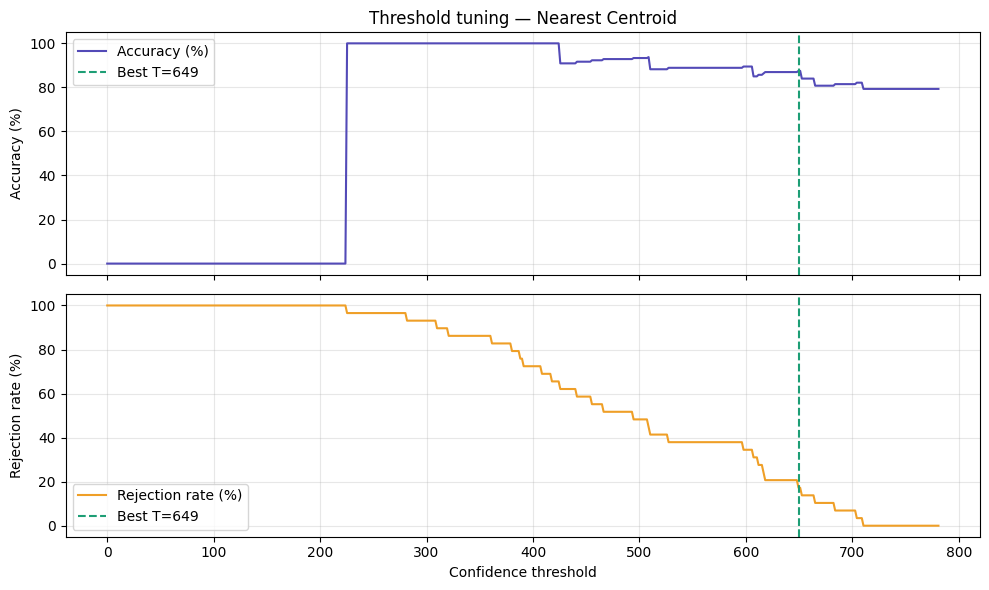


Threshold 649.4 saved to model/scratch_model.pkl


In [24]:
# Threshold tuning for Nearest Centroid
# ─────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

# Get all confidences and true/pred labels
results = clf.predict(X_te_lda)
y_pred  = np.array([r[0] for r in results])
y_conf  = np.array([r[1] for r in results])

print("Confidence range on test set:")
print(f"  Correct predictions   — min: {y_conf[y_pred==y_test].min():.1f}  max: {y_conf[y_pred==y_test].max():.1f}")
print(f"  Incorrect predictions — min: {y_conf[y_pred!=y_test].min():.1f}  max: {y_conf[y_pred!=y_test].max():.1f}")

# Sweep thresholds
thresholds  = np.linspace(0, y_conf.max() * 1.1, 500)
accuracies  = []
reject_rates = []

for T in thresholds:
    accepted = y_conf < T
    if accepted.sum() == 0:
        accuracies.append(0)
        reject_rates.append(100)
        continue
    acc = (y_pred[accepted] == y_test[accepted]).sum() / accepted.sum() * 100
    rej = (~accepted).sum() / len(y_test) * 100
    accuracies.append(acc)
    reject_rates.append(rej)

accuracies   = np.array(accuracies)
reject_rates = np.array(reject_rates)

# Find threshold where accuracy is maximised with < 20% rejection
valid = reject_rates < 20
if valid.any():
    best_idx = np.argmax(accuracies * valid)
else:
    best_idx = np.argmax(accuracies)

best_T = thresholds[best_idx]
print(f"\nRecommended threshold : {best_T:.1f}")
print(f"  Accuracy at T       : {accuracies[best_idx]:.1f}%")
print(f"  Rejection rate at T : {reject_rates[best_idx]:.1f}%")

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax1.plot(thresholds, accuracies,   color="#534AB7", label="Accuracy (%)")
ax1.axvline(best_T, color="#1D9E75", linestyle="--", label=f"Best T={best_T:.0f}")
ax1.set_ylabel("Accuracy (%)"); ax1.legend(); ax1.grid(alpha=0.3)
ax1.set_title("Threshold tuning — Nearest Centroid")

ax2.plot(thresholds, reject_rates, color="#EF9F27", label="Rejection rate (%)")
ax2.axvline(best_T, color="#1D9E75", linestyle="--", label=f"Best T={best_T:.0f}")
ax2.set_xlabel("Confidence threshold")
ax2.set_ylabel("Rejection rate (%)"); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Save threshold
import pickle
with open("model/scratch_model.pkl", "rb") as f:
    saved = pickle.load(f)
saved["threshold"] = best_T
with open("model/scratch_model.pkl", "wb") as f:
    pickle.dump(saved, f)
print(f"\nThreshold {best_T:.1f} saved to model/scratch_model.pkl")